In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[3,5,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('african_crises.csv')
# Select features and target variable
# Example: using 'inflation_annual_cpi' and 'exch_usd' as input features
# and 'banking_crisis' as the target (converted to numeric)
'''features = df[['year', 'systemic_crisis', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 
               'independence', 'currency_crises', 'inflation_annual_cpi', 'exch_usd']]'''

features = df[['year', 'inflation_annual_cpi', 'exch_usd']]
features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['banking_crisis'].map({'crisis': 1, 'no_crisis': -1}).values

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}

# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1059, 3]), torch.Size([1059]))

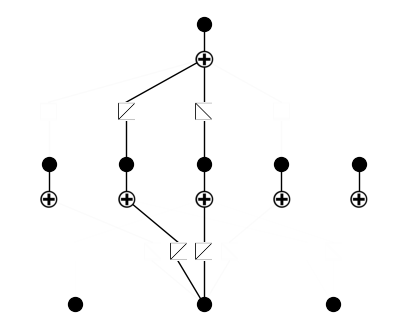

In [3]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

| train_loss: 2.45e+00 | test_loss: 2.45e+00 | reg: 3.90e+01 | : 100%|█| 50/50 [00:29<00:00,  1.68it


saving model version 0.1


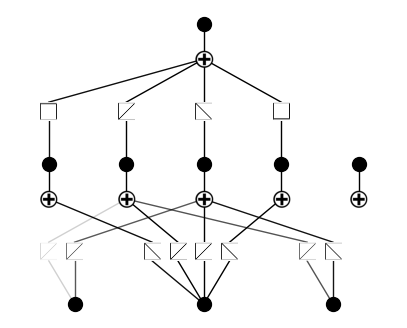

In [4]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

saving model version 0.2


| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.25e+01 | : 100%|█| 50/50 [00:22<00:00,  2.25it

saving model version 0.3


{'train_loss': [array(26.2197, dtype=float32),
  array(26.219698, dtype=float32),
  array(17.362873, dtype=float32),
  array(10.420201, dtype=float32),
  array(5.0498004, dtype=float32),
  array(2.5252535, dtype=float32),
  array(0.8772021, dtype=float32),
  array(0.572674, dtype=float32),
  array(0.57223755, dtype=float32),
  array(0.5722081, dtype=float32),
  array(0.5722045, dtype=float32),
  array(0.5722045, dtype=float32),
  array(0.5722044, dtype=float32),
  array(0.57220435, dtype=float32),
  array(0.57220435, dtype=float32),
  array(0.57220227, dtype=float32),
  array(0.57220227, dtype=float32),
  array(0.57220227, dtype=float32),
  array(0.57220227, dtype=float32),
  array(0.57219744, dtype=float32),
  array(0.57219744, dtype=float32),
  array(0.5721974, dtype=float32),
  array(0.5721791, dtype=float32),
  array(0.572179, dtype=float32),
  array(0.572179, dtype=float32),
  array(0.5721791, dtype=float32),
  array(0.572179, dtype=float32),
  array(0.5721791, dtype=float32),
  a

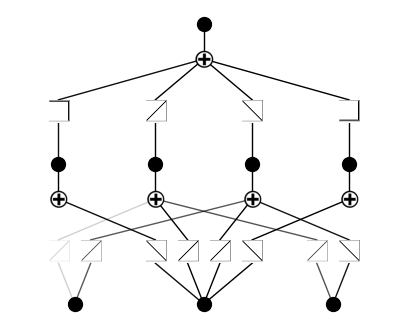

In [5]:
model = model.prune()
model.plot()
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)

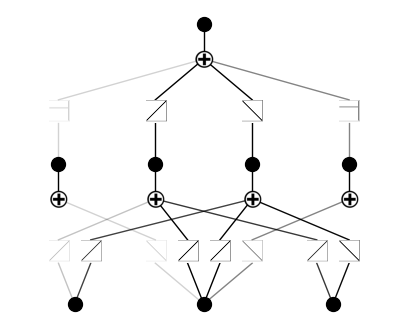

In [6]:
model.plot()

| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.25e+01 | : 100%|█| 50/50 [00:07<00:00,  6.54it


saving model version 0.4
saving model version 0.5


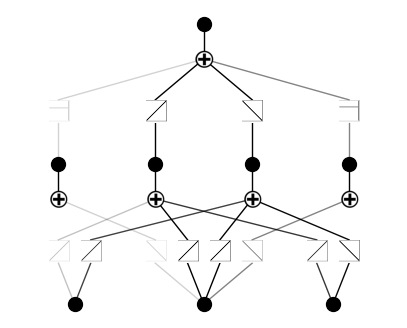

In [7]:
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(5)
model.plot()

| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.25e+01 | : 100%|█| 50/50 [00:07<00:00,  6.44it


saving model version 0.6
saving model version 0.7


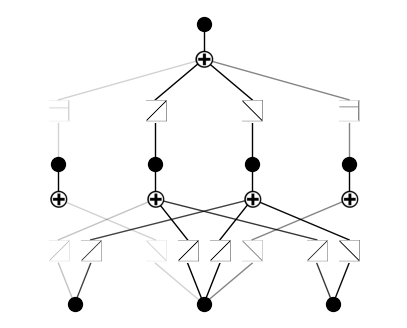

In [8]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(10)
model.plot()

| train_loss: 5.72e-01 | test_loss: 5.72e-01 | reg: 2.24e+01 | : 100%|█| 50/50 [00:12<00:00,  4.00it


saving model version 0.8
saving model version 0.9


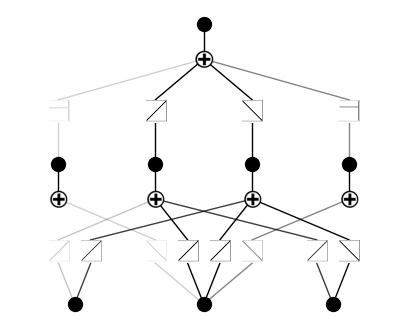

In [9]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model = model.refine(25)
model.plot()

| train_loss: 5.69e-01 | test_loss: 5.69e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:19<00:00,  2.56it


saving model version 0.10


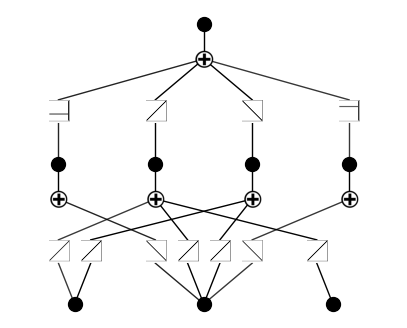

In [10]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

| train_loss: 5.69e-01 | test_loss: 5.69e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:04<00:00, 10.08it


saving model version 0.11


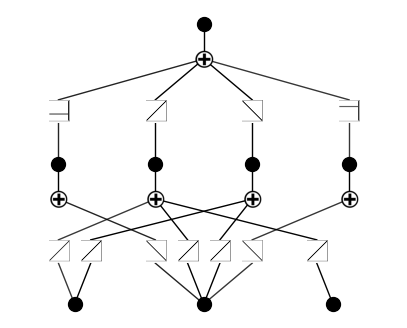

In [11]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)
model.plot()

In [12]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(formula)

fixing (0,0,0) with 0
fixing (0,0,1) with x, r2=1.0000003576278687, c=1
fixing (0,0,2) with x, r2=1.0000003576278687, c=1
fixing (0,0,3) with 0
fixing (0,1,0) with x, r2=1.0000009536743164, c=1
fixing (0,1,1) with x, r2=1.0000009536743164, c=1
fixing (0,1,2) with x, r2=1.0000003576278687, c=1
fixing (0,1,3) with x, r2=1.0000007152557373, c=1
fixing (0,2,0) with 0
fixing (0,2,1) with x, r2=0.9999998807907104, c=1
fixing (0,2,2) with x, r2=0.9999563097953796, c=1
fixing (0,2,3) with 0
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,1,0) with x, r2=1.0000003576278687, c=1
fixing (1,2,0) with x, r2=1.0000003576278687, c=1
fixing (1,3,0) with 0, r2=0.0, c=0
saving model version 0.12


-420590250192201*x_1/1000000000000000000 + 192696887962797*x_2/100000000000000000000000 + 58736329342123*x_3/500000000000000000 - 137248522057817/250000000000000000

In [13]:
ex_round(formula, 4)

-0.0004*x_1 + 0.0001*x_3 - 0.0005